# Project 2 — Notebook 08: Zone 1 Site Risk Profiling
### Identifying High-Density Recurring-Fault Sites for Preventive Maintenance

---

**Context (from Project 1 REC-04):**
Zone 1 (Caloocan, Navotas, Valenzuela) has the highest fault density in NCR at
**9.4 faults/site across only 456 sites**. The same infrastructure is generating
repeated field workload. Preventive maintenance on the top recurring-fault sites
is the priority intervention.

**Questions this notebook answers:**
- Which specific sites in Zone 1 are driving disproportionate repeat alarm volume?
- What fault types and NE categories are concentrated at these sites?
- How much MTTR and field time does the top-N site cohort account for?
- What does a prioritised maintenance schedule look like?

> This methodology is zone-agnostic and can be reapplied to any zone in later projects.

## 1. Setup

In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
%matplotlib inline

os.chdir(os.path.join('..', '..'))
if os.path.abspath(os.getcwd()) not in sys.path:
    sys.path.insert(0, os.path.abspath(os.getcwd()))

from config import PROFESSIONAL_PALETTE, RFO_PALETTE

df = pd.read_csv('output/cleaned_fault_ticket.csv')
z1 = df[df['ZONE'] == 'ZONE 1'].copy()

print(f"✅ Zone 1: {len(z1):,} tickets · {z1['Area'].nunique()} unique sites")
print(f"   Fault density: {len(z1)/z1['Area'].nunique():.1f} faults/site")

✅ Zone 1: 4,306 tickets · 456 unique sites
   Fault density: 9.4 faults/site


## 2. Site Fault Frequency Ranking

In [2]:
site_profile = (z1.groupby('SiteName')
                .agg(
                    Total_Tickets  = ('TICKETID', 'count'),
                    Avg_MTTR       = ('OUTAGEDURATION', 'mean'),
                    SLA_Rate       = ('SLA_Compliant', 'mean'),
                    Unique_RFOs    = ('Standardized RFO', 'nunique'),
                    Unique_NE      = ('NE_Category', 'nunique'),
                )
                .reset_index()
                .sort_values('Total_Tickets', ascending=False))

site_profile['SLA_Rate'] *= 100
site_profile['Rank'] = range(1, len(site_profile) + 1)
site_profile['Cumulative_Pct'] = site_profile['Total_Tickets'].cumsum() / site_profile['Total_Tickets'].sum() * 100

top10_count = site_profile.head(10)['Total_Tickets'].sum()
top20_count = site_profile.head(20)['Total_Tickets'].sum()
total_count = site_profile['Total_Tickets'].sum()

print("=" * 60)
print("ZONE 1 — SITE FAULT CONCENTRATION")
print("=" * 60)
print(f"  Total sites  : {len(site_profile):,}")
print(f"  Total tickets: {total_count:,}")
print(f"  Top 10 sites : {top10_count:,} ({top10_count/total_count*100:.1f}% of Zone 1)")
print(f"  Top 20 sites : {top20_count:,} ({top20_count/total_count*100:.1f}% of Zone 1)")

display(Markdown("### Top 20 Highest-Frequency Sites"))
display(site_profile.head(20)[['Rank','SiteName','Total_Tickets','Avg_MTTR','SLA_Rate','Unique_RFOs','Unique_NE']]
    .style.hide(axis='index')
    .format({'Total_Tickets':'{:,}','Avg_MTTR':'{:.0f}h','SLA_Rate':'{:.1f}%'})
    .background_gradient(subset=['Total_Tickets'], cmap='Oranges')
    .background_gradient(subset=['Avg_MTTR'],      cmap='RdYlGn_r', vmin=20, vmax=120)
    .background_gradient(subset=['SLA_Rate'],      cmap='RdYlGn',   vmin=70, vmax=95)
    .set_caption('Table 1 — Zone 1 Top 20 Recurring-Fault Sites')
    .set_table_styles([
        {'selector':'caption','props':[('font-size','12px'),('font-weight','bold'),('text-align','left'),('padding-bottom','6px')]},
        {'selector':'th',     'props':[('background-color','#2c3e50'),('color','white'),('font-size','11px'),('padding','7px 10px')]},
        {'selector':'td',     'props':[('padding','6px 10px'),('font-size','11px'),('text-align','center')]},
    ])
)

ZONE 1 — SITE FAULT CONCENTRATION
  Total sites  : 456
  Total tickets: 4,306
  Top 10 sites : 659 (15.3% of Zone 1)
  Top 20 sites : 978 (22.7% of Zone 1)


### Top 20 Highest-Frequency Sites

Rank,SiteName,Total_Tickets,Avg_MTTR,SLA_Rate,Unique_RFOs,Unique_NE
1,Region3_CALOOCAN CITY_712a8f02,178,433h,70.8%,12,4
2,Region3_CALOOCAN CITY_260e8b5e,130,246h,73.8%,7,4
3,Region3_CALOOCAN CITY_70cf9ccf,54,13h,88.9%,8,1
4,Region3_CALOOCAN CITY_800ad72d,50,27h,76.0%,4,1
5,Region3_VALENZUELA CITY_f28b9379,45,18h,93.3%,8,2
6,Region3_VALENZUELA CITY_d1696bd1,45,36h,86.7%,6,2
7,Region3_CALOOCAN CITY_51dff01b,41,1h,92.7%,6,1
8,Region3_CALOOCAN CITY_2f023980,40,4h,95.0%,9,2
9,Region3_NAVOTAS CITY_0fa1f49e,38,25h,94.7%,9,1
10,Region3_VALENZUELA CITY_d2592fbb,38,24h,81.6%,9,1


## 3. Pareto Chart — Fault Concentration

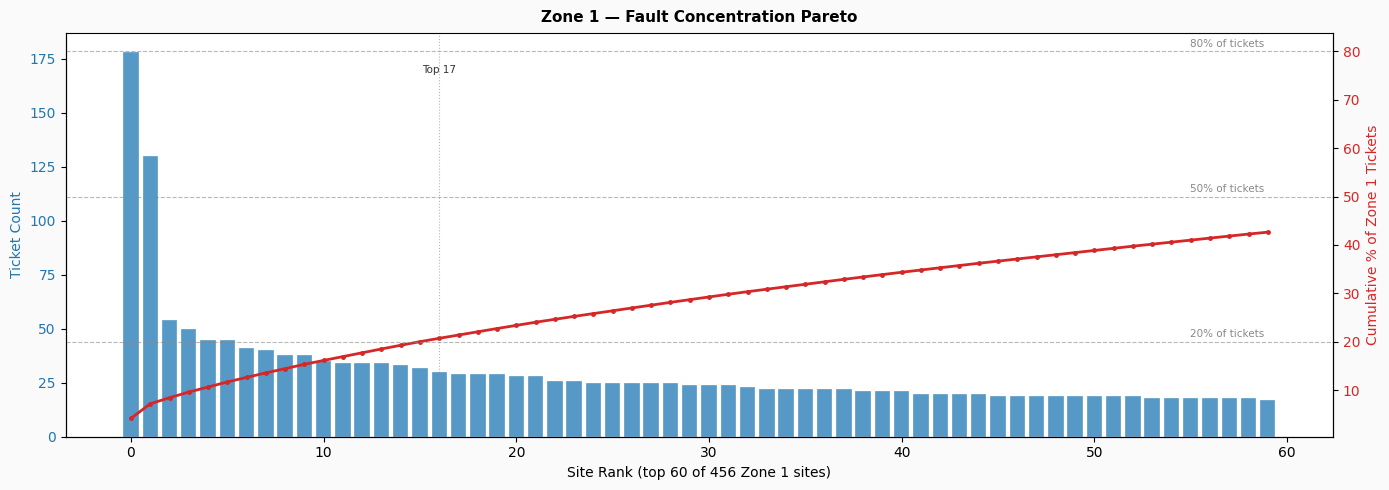

In [3]:
fig, ax1 = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#fafafa')
ax2 = ax1.twinx()

top_n = min(60, len(site_profile))
x = np.arange(top_n)

ax1.bar(x, site_profile.head(top_n)['Total_Tickets'],
        color='#1f77b4', alpha=0.75, edgecolor='white', linewidth=0.3)
ax2.plot(x, site_profile.head(top_n)['Cumulative_Pct'],
         color='#d62728', linewidth=2, marker='o', markersize=2.5)

for threshold in [20, 50, 80]:
    idx  = (site_profile['Cumulative_Pct'] >= threshold).idxmax()
    rank = site_profile.loc[idx, 'Rank']
    ax2.axhline(threshold, color='#888', linestyle='--', linewidth=0.8, alpha=0.6)
    ax2.text(top_n * 0.98, threshold + 0.5, f'{threshold}% of tickets',
             ha='right', va='bottom', fontsize=7.5, color='#888')
    if rank <= top_n:
        ax2.axvline(rank - 1, color='#888', linestyle=':', linewidth=0.8, alpha=0.6)
        ax1.text(rank - 1, ax1.get_ylim()[1] * 0.92,
                 f'Top {rank}', ha='center', va='top', fontsize=7.5, color='#333')

ax1.set_xlabel(f'Site Rank (top {top_n} of {len(site_profile)} Zone 1 sites)', fontsize=10)
ax1.set_ylabel('Ticket Count', fontsize=10, color='#1f77b4')
ax2.set_ylabel('Cumulative % of Zone 1 Tickets', fontsize=10, color='#d62728')
ax1.set_title('Zone 1 — Fault Concentration Pareto', fontsize=11, fontweight='bold', pad=8)
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax2.tick_params(axis='y', labelcolor='#d62728')
ax1.spines['top'].set_visible(False)

plt.tight_layout()
os.makedirs('reports/figures/project2_ncr', exist_ok=True)
plt.savefig('reports/figures/project2_ncr/08_z1_pareto.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. RFO Profile — Top 20 Sites vs Rest of Zone 1

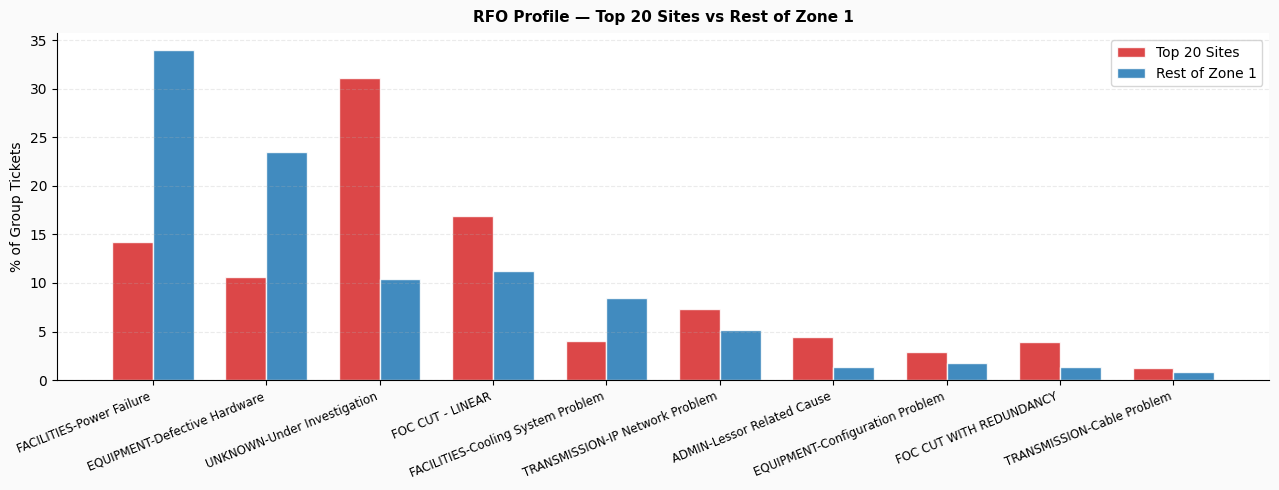

In [4]:
top20_sites = site_profile.head(20)['SiteName'].tolist()
z1_top20 = z1[z1['SiteName'].isin(top20_sites)]
z1_rest  = z1[~z1['SiteName'].isin(top20_sites)]

rfo_top20 = z1_top20['Standardized RFO'].value_counts(normalize=True) * 100
rfo_rest  = z1_rest['Standardized RFO'].value_counts(normalize=True) * 100
top_rfos  = z1['Standardized RFO'].value_counts().head(10).index.tolist()

compare = pd.DataFrame({
    'Top 20 Sites'  : rfo_top20.reindex(top_rfos, fill_value=0),
    'Rest of Zone 1': rfo_rest.reindex(top_rfos, fill_value=0),
})

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('#fafafa')
x = np.arange(len(compare)); w = 0.36
ax.bar(x - w/2, compare['Top 20 Sites'],  w, label='Top 20 Sites',   color='#d62728', alpha=0.85, edgecolor='white')
ax.bar(x + w/2, compare['Rest of Zone 1'], w, label='Rest of Zone 1', color='#1f77b4', alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(compare.index, fontsize=8.5, rotation=22, ha='right')
ax.set_ylabel('% of Group Tickets', fontsize=10)
ax.set_title('RFO Profile — Top 20 Sites vs Rest of Zone 1', fontsize=11, fontweight='bold', pad=8)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.25, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('reports/figures/project2_ncr/08_z1_top20_rfo_profile.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. NE Category Mix — Top 20 Sites

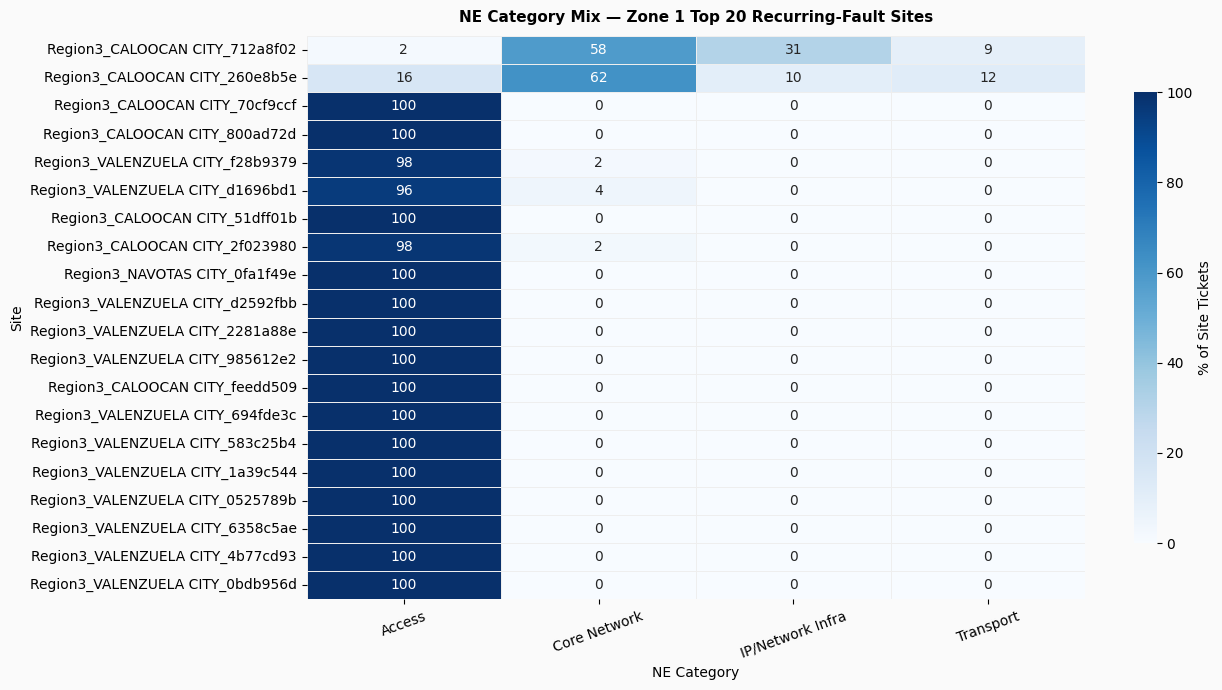

In [5]:
ne_top20 = (z1_top20.groupby(['SiteName','NE_Category']).size().reset_index(name='Count'))
ne_top20['Site_Total'] = ne_top20.groupby('SiteName')['Count'].transform('sum')
ne_top20['Pct'] = ne_top20['Count'] / ne_top20['Site_Total'] * 100

ne_pivot = (ne_top20.pivot_table(index='SiteName', columns='NE_Category', values='Pct', fill_value=0)
             .reindex(top20_sites))

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('#fafafa')
from src.visualization.common_plots import plot_heatmap
plot_heatmap(ax, ne_pivot, pivot=False,
             title='NE Category Mix — Zone 1 Top 20 Recurring-Fault Sites',
             cmap='Blues', fmt='.0f',
             cbar_label='% of Site Tickets', cbar_shrink=0.8,
             x_label='NE Category', y_label='Site',
             x_rotation=20, y_rotation=0)
plt.tight_layout()
plt.savefig('reports/figures/project2_ncr/08_z1_ne_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Preventive Maintenance Priority List

In [6]:
sp = site_profile.head(20).copy()

def norm(s):
    mn, mx = s.min(), s.max()
    return (s - mn) / (mx - mn + 1e-9) * 100

sp['Score_Volume'] = norm(sp['Total_Tickets'])
sp['Score_MTTR']   = norm(sp['Avg_MTTR'])
sp['Score_SLA']    = norm(100 - sp['SLA_Rate'])
sp['Risk_Score']   = (sp['Score_Volume']*0.5 + sp['Score_MTTR']*0.3 + sp['Score_SLA']*0.2).round(1)
sp = sp.sort_values('Risk_Score', ascending=False)
sp['PM_Priority'] = range(1, len(sp)+1)

display(Markdown("### Preventive Maintenance Priority List — Zone 1"))
display(sp[['PM_Priority','SiteName','Total_Tickets','Avg_MTTR','SLA_Rate','Risk_Score']]
    .style.hide(axis='index')
    .format({'Total_Tickets':'{:,}','Avg_MTTR':'{:.0f}h','SLA_Rate':'{:.1f}%','Risk_Score':'{:.1f}'})
    .background_gradient(subset=['Risk_Score'], cmap='RdYlGn_r', vmin=0, vmax=100)
    .set_caption('Table 2 — PM Priority  |  Risk Score = 50% Volume + 30% MTTR + 20% SLA breach')
    .set_table_styles([
        {'selector':'caption','props':[('font-size','12px'),('font-weight','bold'),('text-align','left'),('padding-bottom','6px')]},
        {'selector':'th',     'props':[('background-color','#2c3e50'),('color','white'),('font-size','11px'),('padding','7px 10px')]},
        {'selector':'td',     'props':[('padding','6px 10px'),('font-size','11px'),('text-align','center')]},
    ])
)
print("\nTarget: reduce Zone 1 fault density from 9.4 to ≤7.5 faults/site.")

### Preventive Maintenance Priority List — Zone 1

PM_Priority,SiteName,Total_Tickets,Avg_MTTR,SLA_Rate,Risk_Score
1,Region3_CALOOCAN CITY_712a8f02,178,433h,70.8%,100.0
2,Region3_CALOOCAN CITY_260e8b5e,130,246h,73.8%,68.8
3,Region3_CALOOCAN CITY_800ad72d,50,27h,76.0%,25.2
4,Region3_VALENZUELA CITY_2281a88e,35,235h,91.4%,24.1
5,Region3_VALENZUELA CITY_d2592fbb,38,24h,81.6%,17.3
6,Region3_VALENZUELA CITY_d1696bd1,45,36h,86.7%,16.9
7,Region3_CALOOCAN CITY_70cf9ccf,54,13h,88.9%,16.8
8,Region3_VALENZUELA CITY_985612e2,34,18h,82.4%,14.9
9,Region3_VALENZUELA CITY_6358c5ae,29,45h,86.2%,12.5
10,Region3_VALENZUELA CITY_0bdb956d,29,4h,82.8%,12.0



Target: reduce Zone 1 fault density from 9.4 to ≤7.5 faults/site.


## 7. Next Steps

→ **Notebook 09** — Project 2 Business Summary and Recommendations.